In [1]:
num_particles = 100
run_time_days = 20
time_step_minutes = 20
out_put_step_hours = 6

#initial position
lon0 = -50
lon1 = -48
lat0 = 1
lat1 = -0.5

depth_min = 1 #todo: figure near-surface depths 
depth_max = 10

offset = 200
ref_date = "2022-06-01"
#reproducibility
rdm_seed = 4567

#paths
pathUV= '/work/bk1450/b383184/Amazon/Atlantic/data/UV'
pathW= '/work/bk1450/b383184/Amazon/Atlantic/data/W'
pathT = "/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp"
pathS = "/work/bk1450/b383184/Amazon/Atlantic/data/tracers/sal"

In [2]:
import numpy as np

In [3]:
out_path = f'../data/tracks_{rdm_seed}/' #path to store the particle zarr

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
start_time

np.datetime64('2022-12-18')

## Particles from the Plume to the Atlantic

* Release particles from the plume every 5 days for 4 years (2022-2025)
* Release time 2022 to 2025
* Number of particles =  10_000
* Release depth = (0,10)
* Tracking salinity and temperature

In [4]:
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob

In [5]:
np.random.seed(rdm_seed)

### Copernicus Data (A grid)

In [6]:
ufiles = sorted(glob(f"{pathUV}/U_20*.nc"))
vfiles = sorted(glob(f"{pathUV}/V_20*.nc"))
wfiles = sorted(glob(f"{pathW}/W_20*.nc"))
Tfiles = sorted(glob(f"{pathT}/temp_20*.nc"))
Sfiles = sorted(glob(f"{pathS}/sal_20*.nc"))

In [7]:
print(Tfiles)

['/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2022_06.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2022_07.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2022_08.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2022_09.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2022_10.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2022_11.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2022_12.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2023_01.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2023_02.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2023_03.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2023_04.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2023_05.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp_2023_06.nc', '/work/bk1450/b383184/Amazon/Atlantic

In [8]:
## define the fieldset
filenames = {"U": ufiles,
             "V": vfiles,
             "W": wfiles,
             "T": Tfiles,
             "S": Sfiles,
            }

variables = {"U": "uo",
             "V": "vo",
             "W": "wo",
             "T": "thetao",
             "S": "so"
            }

dimensions={'lon':'longitude',
            'lat':'latitude',
            'time':'time',
            'depth': "depth",
           }
## everything is on an A grid so not T points for Sal and Temp, but will change for the longer track

## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
)

In [9]:
start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)
start_depth = np.random.uniform(depth_min,depth_max,size=num_particles)
start_times = np.datetime64(start_time)

In [10]:
def SampleTS(particle, fieldset, time):
    # z = particle.depth
    # Optional: clamp depth to tracer range if needed
    # zmin, zmax can be added as constants if you want; otherwise omit.
    particle.temp = fieldset.T[time, particle.depth, particle.lat, particle.lon]
    particle.sal  = fieldset.S[time, particle.depth, particle.lat, particle.lon]

In [11]:
## particle age
def Age(particle, fieldset, time):
    particle.age += particle.dt / 3600

In [12]:
class SampleParticle(JITParticle):
    """
    Add variables to the standard particle class.
    Particles will sample temperature and salinity of the particle.
    """

    temp = Variable("temp", dtype=np.float32,initial=np.nan)
    sal = Variable("sal", dtype=np.float32,initial=np.nan)
    age = Variable("age", dtype=np.float32,initial=0.0)

In [13]:
# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    pclass = SampleParticle,
    lon = start_lon,
    lat = start_lat,
    depth=start_depth,
    time=start_times
) 


out_fn = f'Parcels_run_{rdm_seed}_{start_time}.zarr'

output_file = pset.ParticleFile(
    name=out_path+out_fn,
    outputdt=timedelta(hours=out_put_step_hours),
    chunks = (num_particles,int(run_time_days*24/out_put_step_hours/4))
)

In [14]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [15]:
## Execute particles
pset.execute(
    [Age,SampleTS,AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=run_time_days),
    dt=timedelta(minutes=time_step_minutes),
    output_file= output_file
)

INFO: Output files are stored in ../data/tracks_4567/Parcels_run_4567_2022-12-18.zarr.
100%|██████████| 1728000.0/1728000.0 [04:56<00:00, 5823.42it/s]


### Plotting

In [16]:
import xarray as xr

In [17]:
out_path = f'../data/tracks_{rdm_seed}/'
# out_fn = 'Parcels_run_692' 

ds_traj = xr.open_zarr(out_path+out_fn)
# ds_traj = ds_traj.compute()
ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 257kB
Dimensions:     (trajectory: 100, obs: 80)
Coordinates:
  * obs         (obs) int32 320B 0 1 2 3 4 5 6 7 8 ... 72 73 74 75 76 77 78 79
  * trajectory  (trajectory) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
Data variables:
    age         (trajectory, obs) float32 32kB 0.3333 6.333 12.33 ... nan nan
    lat         (trajectory, obs) float32 32kB 0.457 0.4607 0.4642 ... nan nan
    lon         (trajectory, obs) float32 32kB -49.28 -49.28 -49.28 ... nan nan
    sal         (trajectory, obs) float32 32kB 7.532 7.482 7.422 ... nan nan nan
    temp        (trajectory, obs) float32 32kB 28.8 28.78 28.76 ... nan nan nan
    time        (trajectory, obs) datetime64[ns] 64kB 2022-12-18 ... NaT
    z           (trajectory, obs) float32 32kB 4.821 4.846 4.872 ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleAgeSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

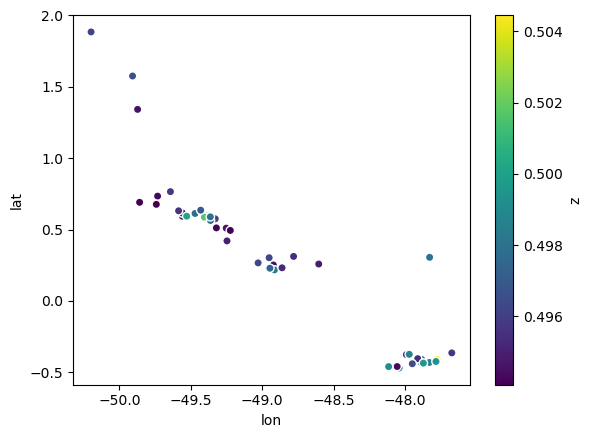

In [18]:
last_valid = ds_traj.lat.notnull().astype(int).diff('obs',label='lower')==-1
ds_traj.where(last_valid).mean('obs').compute().plot.scatter(x='lon',y='lat',hue='z')

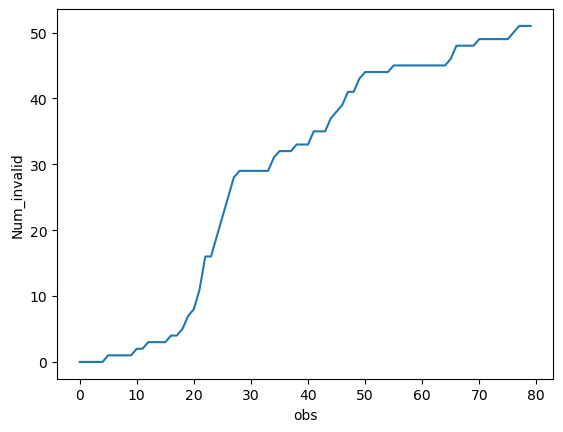

In [19]:
import matplotlib.pyplot as plt
ds_traj.lat.isnull().sum('trajectory').rename('Num_invalid').plot()
plt.show()

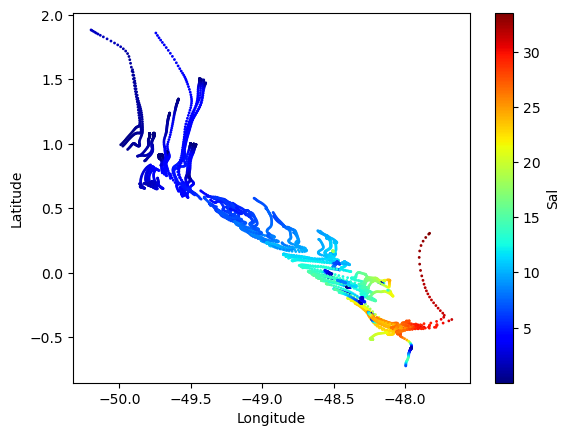

In [20]:
fig, ax = plt.subplots()
sc = ax.scatter(ds_traj.lon.values, ds_traj.lat.values,
                c=ds_traj.sal.values, s=1, cmap='jet')
cb = fig.colorbar(sc, ax=ax, label='Sal')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.show()

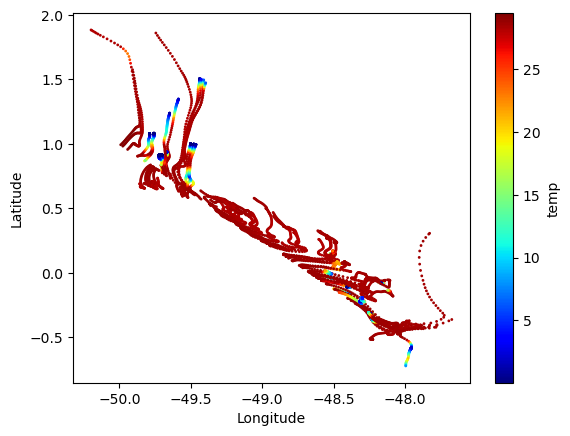

In [21]:
fig, ax = plt.subplots()
sc = ax.scatter(ds_traj.lon.values, ds_traj.lat.values,
                c=ds_traj.temp.values, s=1, cmap='jet')
cb = fig.colorbar(sc, ax=ax, label='temp')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.show()

In [22]:
ds_traj.temp.min()

<xarray.DataArray 'temp' ()> Size: 8B
array(0.0153376)

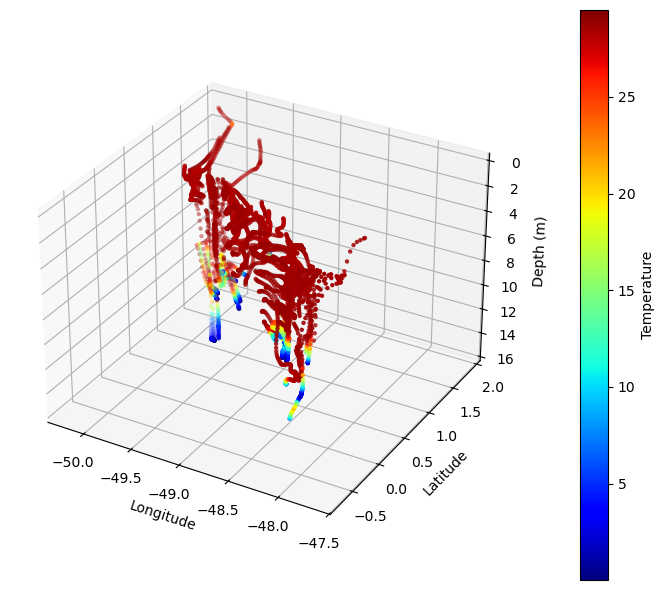

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D

lon  = np.asarray(ds_traj.lon.values).ravel()
lat  = np.asarray(ds_traj.lat.values).ravel()
z    = np.asarray(ds_traj.z.values).ravel()
temp = np.asarray(ds_traj.temp.values).ravel()

# Common finite mask (avoid length mismatch)
m = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(z) & np.isfinite(temp)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(lon[m], lat[m], z[m],
                c=temp[m], s=10, cmap='jet', edgecolors='none')

cb = fig.colorbar(sc, ax=ax, pad=0.1)
cb.set_label('Temperature')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_zlabel('Depth (m)')
ax.invert_zaxis()
plt.tight_layout(); plt.show()

In [24]:
cold = ds_traj.temp.values < 10  # °C
print("n cold points:", cold.sum())
print("example lon/lat/z:", ds_traj.lon.values[cold][:5],
      ds_traj.lat.values[cold][:5], ds_traj.z.values[cold][:5])

n cold points: 997
example lon/lat/z: [-48.383747 -48.384926 -48.38731  -48.39075  -48.394245] [-0.11622465 -0.11654868 -0.11632513 -0.1156326  -0.11474237] [8.656944 8.732905 8.799372 8.858223 8.907994]


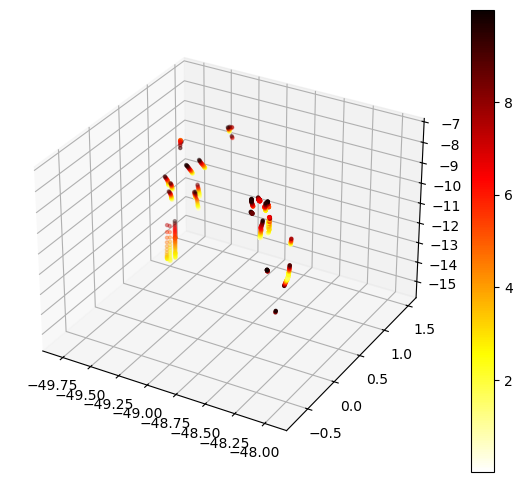

In [25]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(ds_traj.lon.values[cold],ds_traj.lat.values[cold],-ds_traj.z.values[cold],c=ds_traj.temp.values[cold], 
                 marker='.',cmap='hot_r')
plt.colorbar(sc)
plt.show()

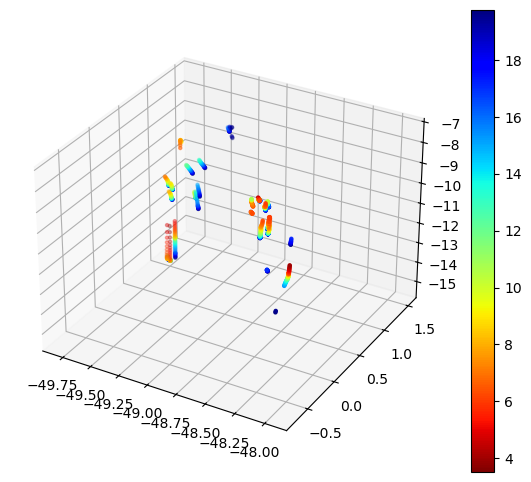

Text(0.5, 1.0, 'Age [day]')

In [28]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(ds_traj.lon.values[cold],ds_traj.lat.values[cold],-ds_traj.z.values[cold],c=ds_traj.age.values[cold]/24, 
                 marker='.',cmap='jet_r')
plt.colorbar(sc)
plt.show()
plt.title("Age [day]")

In [27]:
import pandas as pd

df = pd.DataFrame({"lon":ds_traj.lon.values[cold],
                   "lat":ds_traj.lat.values[cold],
                   "z":ds_traj.z.values[cold]
                  })
df.to_csv(f'Cold_points_track_{rdm_seed}.csv')